# Model-Tests

In [2]:
%matplotlib inline
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
import pandas as pd
import kagglehub

path = kagglehub.dataset_download("nelgiriyewithana/world-stock-prices-daily-updating")

print("Path to dataset files:", path)
data_path = path+"\World-Stock-Prices-Dataset.csv"
data = pd.read_csv(data_path)

<>:9: SyntaxWarning: invalid escape sequence '\W'
<>:9: SyntaxWarning: invalid escape sequence '\W'
C:\Users\s3phi\AppData\Local\Temp\ipykernel_21952\942347233.py:9: SyntaxWarning: invalid escape sequence '\W'
  data_path = path+"\World-Stock-Prices-Dataset.csv"
c:\workspace\StockPredictor\StockPredictor_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\s3phi\.cache\kagglehub\datasets\nelgiriyewithana\world-stock-prices-daily-updating\versions\388


In [3]:
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains
0,2025-06-23 00:00:00-04:00,6.110000,6.420000,6.030000,6.370000,12015400.0,0.0,0.0,peloton,PTON,fitness,usa,NaN
1,2025-06-23 00:00:00-04:00,98.000000,98.120003,94.449997,97.370003,1609100.0,0.0,0.0,crocs,CROX,footwear,usa,NaN
2,2025-06-23 00:00:00-04:00,69.139999,69.809998,68.970001,69.739998,21815200.0,0.0,0.0,the coca-cola company,KO,food & beverage,usa,NaN
3,2025-06-23 00:00:00-04:00,112.879997,114.769997,112.070000,114.559998,36600.0,0.0,0.0,adidas,ADDYY,apparel,germany,NaN
4,2025-06-23 00:00:00-04:00,296.820007,299.869995,291.880005,299.630005,3094700.0,0.0,0.0,american express,AXP,finance,usa,NaN


In [4]:
#arr = data["Brand_Name"].unique()
#for i in arr:
#    print(i)

In [5]:
df = pd.DataFrame(data)
df_apple = df.loc[df["Brand_Name"] == "google", ["Date", "Close", "Brand_Name"]]
display(df_apple)

,Date,Close,Brand_Name
38,2025-06-23 00:00:00-04:00,165.190002,google
110,2025-06-20 00:00:00-04:00,166.639999,google
138,2025-06-20 00:00:00-04:00,166.639999,google
226,2025-06-18 00:00:00-04:00,173.320007,google
256,2025-06-18 00:00:00-04:00,173.320007,google
...,...,...,...
269265,2004-08-25 00:00:00-04:00,2.652653,google
269287,2004-08-24 00:00:00-04:00,2.624374,google
269351,2004-08-23 00:00:00-04:00,2.737738,google
269358,2004-08-20 00:00:00-04:00,2.710460,google


In [6]:
df_apple_preproc = df_apple.rename(columns={"Date": "timestamp", "Close": "target", "Brand_Name": "item_id"})
df_apple_preproc["item_id"] = df_apple_preproc['item_id'].astype("string")
df_apple_preproc["timestamp"] = df_apple_preproc['timestamp'].astype("string")
timecut = df_apple_preproc["timestamp"].str.slice(stop=10) #Cut hh:mm:ss and timezone
df_apple_preproc["timestamp"] = timecut
df_apple_preproc["timestamp"] = pd.to_datetime(timecut) #convert string into datetime64
df_apple_reordered =  df_apple_preproc[['item_id', 'timestamp', 'target']] #Reordering columns
df_irregular = TimeSeriesDataFrame(
    pd.DataFrame(df_apple_reordered)
)
df_regular = df_irregular.convert_frequency(freq="D")
df_filled = df_regular.fill_missing_values()
data = TimeSeriesDataFrame.from_data_frame(
    df = df_filled,
    id_column="item_id",
    timestamp_column="timestamp"
)

In [7]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

prediction_length = 10
train_data, test_data = data.train_test_split(prediction_length)

predictor = TimeSeriesPredictor(prediction_length=prediction_length, freq="D").fit(
    train_data, presets="bolt_base", hyperparameters={"Chronos": {"fine_tune": True, "fine_tune_lr": 1e-5, "fine_tune_steps": 7000}},
    time_limit=30,
)

Beginning AutoGluon training... Time limit = 30s
AutoGluon will save models to 'c:\workspace\CrimeMap\AutogluonModels\ag-20250624_162935'
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          8
GPU Count:          0
Memory Avail:       1.97 GB / 15.70 GB (12.5%)
Disk Space Avail:   39.67 GB / 475.50 GB (8.3%)
Setting presets to: bolt_base

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'freq': 'D',
 'hyperparameters': {'Chronos': {'fine_tune': True,
                                 'fine_tune_lr': 1e-05,
                                 'fine_tune_steps': 7000}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 10,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,

Model not specified in predict, will default to the model with the best validation score: Chronos[autogluon__chronos-bolt-small]


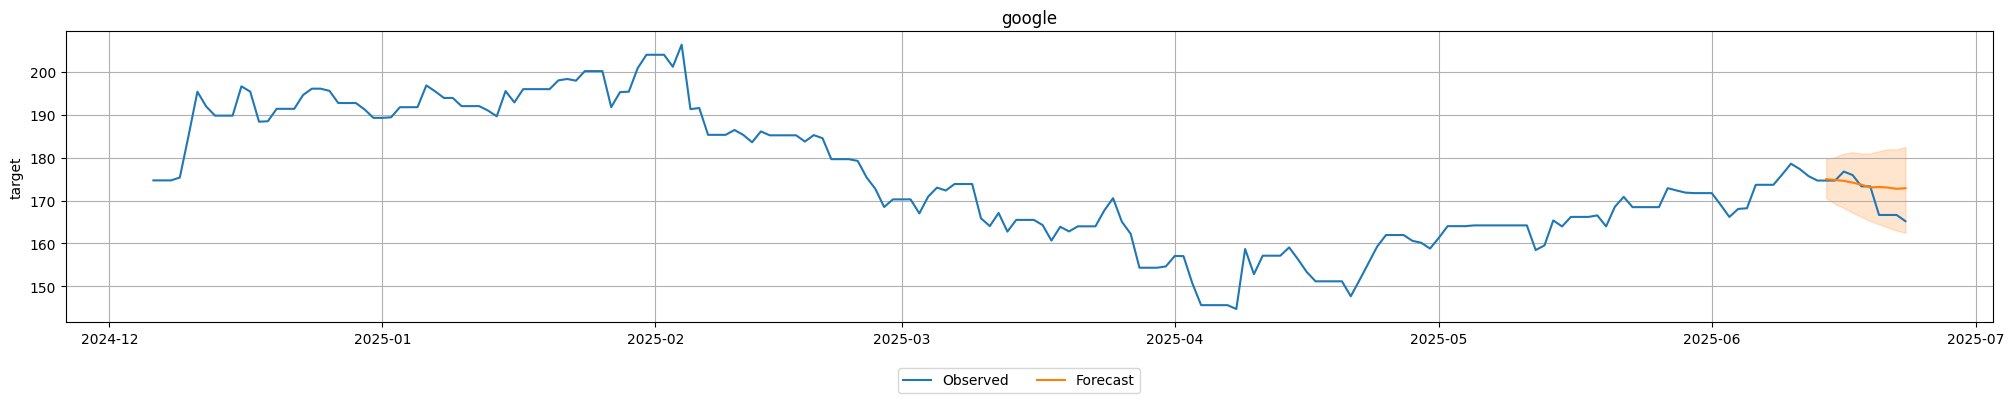

In [8]:
predictions = predictor.predict(train_data)
predictor.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);

Model not specified in predict, will default to the model with the best validation score: Chronos[autogluon__chronos-bolt-small]


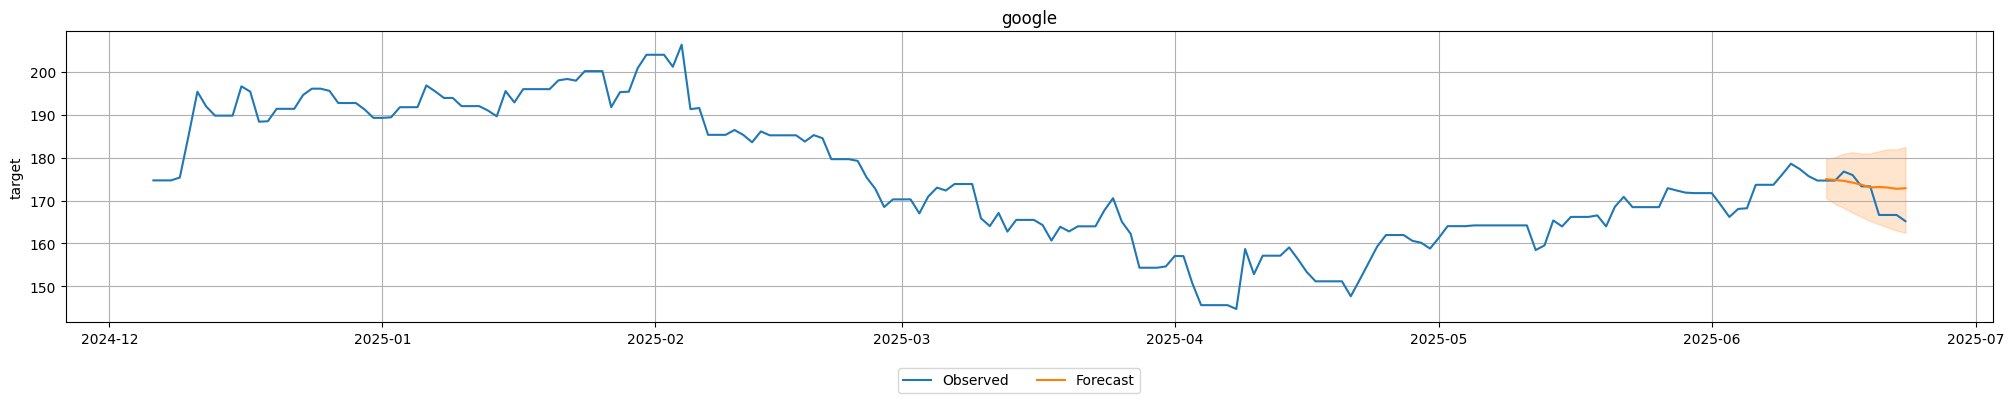

In [9]:
%matplotlib inline
predictions = predictor.predict(train_data)
predictor.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);

In [10]:
model_path = "./AutogluonModels/ag-20250623_071832/"

predictor = TimeSeriesPredictor.load(model_path)


############################## WARNING ##############################
	Predictor Version: 1.3.1
	Current Version:   1.3.0
############################## WARNING ##############################



AssertionError: Predictor was created on version 1.3.1 but is being loaded with version 1.3.0. Please ensure the versions match to avoid instability. While it is NOT recommended, this error can be bypassed by specifying `require_version_match=False`. Exceptions encountered after setting `require_version_match=False` may be very cryptic, and in most cases mean that the predictor is fully incompatible with the installed version.

In [ ]:
predictions = predictor.predict(train_data)
predictor.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);

Model not specified in predict, will default to the model with the best validation score: Chronos[autogluon__chronos-bolt-small]
